## More stats to validate the results

In [ ]:
# divided
# /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/divided/176x88x48/variable_voxel_distance/mean_two_landmarks/straight_model/learning_rate/0.0001/19Nov2025-10:01:33-trainID-2

In [1]:
# the data i needed, final results
## cropped size (63, 50, 61)
## fc - org - /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/09Jul2024-12:12:48-trainID-33.3
## fc - retrain - /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/19Nov2025-13:17:24-trainID-33.3
## final_Y_test_pred.npy, Y_test_true.npy, res_test.npy, best_val_Y_CTPre14_pred.npy, Y_CTPre14_true.npy, res_CTPre14.npy
## dsnt - "/data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/u_net_dsnt/turner_results/random_grid_0/14Aug2024-04:36:02-trainID-13.1"
import os
import numpy as np

ret_dir = "/data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/19Nov2025-13:17:24-trainID-33.3"
y_test_true = np.load(os.path.join(ret_dir, "Y_test_true.npy"))
y_test_pred = np.load(os.path.join(ret_dir, "final_Y_test_pred.npy"))
res_test = np.load(os.path.join(ret_dir, "res_test.npy"))

y_CTPre14_true = np.load(os.path.join(ret_dir, "Y_CTPre14_true.npy"))
y_CTPre14_pred = np.load(os.path.join(ret_dir, "best_val_Y_CTPre14_pred.npy"))
res_CTPre14 = np.load(os.path.join(ret_dir, "res_CTPre14.npy"))

In [2]:
# find the maximum error in test set
# find the maximum error in test set (per-landmark, record patient/side/landmark)
patient_names_14 = ['CD', 'DN', 'GS', 'HME', 'LY', 'MG', 'MM', 'NJ', 'RM', 'SL', 'TA', 'TG', 'VPR', 'YJ']

t = np.asarray(y_CTPre14_true, float)   # (28,2,3)
p = np.asarray(y_CTPre14_pred, float)

if t.shape != p.shape:
    raise ValueError(f"y_CTPre14_true/pred shape mismatch: {t.shape} vs {p.shape}")
if t.ndim != 3 or t.shape[1] != 2 or t.shape[2] != 3:
    raise ValueError(f"Unexpected shape for y_CTPre14_true/pred: {t.shape}")

n_results = t.shape[0]
n_patients = n_results // 2
if n_results != 2 * len(patient_names_14):
    raise ValueError(f"Number of results ({n_results}) != 2 * len(patient_names_14) ({2*len(patient_names_14)})")

# prepare per-result voxel scaling (squeeze shapes like (28,1,3) -> (28,3))
res_arr = np.asarray(res_CTPre14)
res_flat = np.squeeze(res_arr)
if res_flat.ndim == 1 and res_flat.size == 3:
    # same scaling for all results
    res_flat = np.tile(res_flat, (n_results, 1))
elif res_flat.shape[0] != n_results or res_flat.shape[1] != 3:
    # attempt reshape if necessary
    try:
        res_flat = res_flat.reshape(n_results, 3)
    except Exception:
        # fallback to uniform 0.15
        res_flat = np.full((n_results, 3), 0.15, dtype=float)

# build per-landmark entries and per-patient dict
entries = []   # list of tuples (err_mm, patient, side, landmark, result_idx, landmark_idx)
patient_errors = {name: {} for name in patient_names_14}

for r in range(n_results):
    patient_idx = r // 2
    patient = patient_names_14[patient_idx]
    side = 'L' if (r % 2) == 0 else 'R'
    for l_idx, landmark_name in enumerate(['ant', 'post']):
        diff_vox = t[r, l_idx] - p[r, l_idx]           # (3,)
        diff_mm = diff_vox * res_flat[r]              # apply per-result voxel spacing
        err_mm = float(np.linalg.norm(diff_mm))
        entries.append((err_mm, patient, side, landmark_name, r, l_idx))
        patient_errors[patient][f"{side}_{landmark_name}"] = err_mm

# sort entries by error descending
entries_sorted = sorted(entries, key=lambda x: x[0], reverse=True)

# also produce a patient-sorted dict by max error (descending)
patient_max = {name: max(patient_errors[name].values()) for name in patient_names_14}
patient_sorted_by_max = dict(sorted(patient_errors.items(), key=lambda kv: float(max(kv[1].values())), reverse=True))

# save results
out_landmarks = os.path.join(ret_dir, "CTPre14_landmark_errors_sorted.npy")
out_patients = os.path.join(ret_dir, "CTPre14_patient_errors_by_landmark.npy")
np.save(out_landmarks, entries_sorted, allow_pickle=True)
np.save(out_patients, patient_sorted_by_max, allow_pickle=True)

# print brief summary (top 10 landmarks and per-patient max)
print("Top landmarks by error (mm):")
for e in entries_sorted[:10]:
    print(f"err={e[0]:.4f} mm  patient={e[1]}  side={e[2]}  landmark={e[3]}  result_idx={e[4]} landmark_idx={e[5]}")

print("\nPer-patient errors (sorted by patient max error):")
for name, errs in patient_sorted_by_max.items():
    vals = [f"{k}:{v:.4f}" for k, v in errs.items()]
    print(f"{name}: " + ", ".join(vals) + f"   max={max(errs.values()):.4f}")

print("Saved:", out_landmarks, out_patients)

Top landmarks by error (mm):
err=1.2644 mm  patient=VPR  side=L  landmark=post  result_idx=24 landmark_idx=1
err=0.8936 mm  patient=VPR  side=L  landmark=ant  result_idx=24 landmark_idx=0
err=0.7905 mm  patient=TG  side=L  landmark=post  result_idx=22 landmark_idx=1
err=0.7610 mm  patient=VPR  side=R  landmark=post  result_idx=25 landmark_idx=1
err=0.7278 mm  patient=VPR  side=R  landmark=ant  result_idx=25 landmark_idx=0
err=0.6835 mm  patient=TA  side=L  landmark=post  result_idx=20 landmark_idx=1
err=0.6519 mm  patient=DN  side=R  landmark=post  result_idx=3 landmark_idx=1
err=0.6018 mm  patient=HME  side=L  landmark=post  result_idx=6 landmark_idx=1
err=0.5722 mm  patient=RM  side=L  landmark=post  result_idx=16 landmark_idx=1
err=0.5678 mm  patient=MM  side=L  landmark=ant  result_idx=12 landmark_idx=0

Per-patient errors (sorted by patient max error):
VPR: L_ant:0.8936, L_post:1.2644, R_ant:0.7278, R_post:0.7610   max=1.2644
TG: L_ant:0.2479, L_post:0.7905, R_ant:0.1794, R_post:0

In [ ]:
# based on the results, may need to check specific patients/landmarks further
# VPR - all
# TG  - LLSCC Post
# TA  - LLSCC Post
# DN  - RLSCC Post
# HME - LLSCC Post 

In [4]:
arr_entities = np.asarray(entries_sorted, dtype=object)
mean_error = np.mean(arr_entities[:,0].astype(float))
print(f"\nMean error across all landmarks: {mean_error:.4f} mm")


Mean error across all landmarks: 0.3751 mm


### Bland–Altman plot
A Bland–Altman plot (also called a difference plot) is a method to compare two measurement techniques or two sets of measurements of the same variable — for example, comparing a new medical imaging algorithm’s output to a gold-standard method.

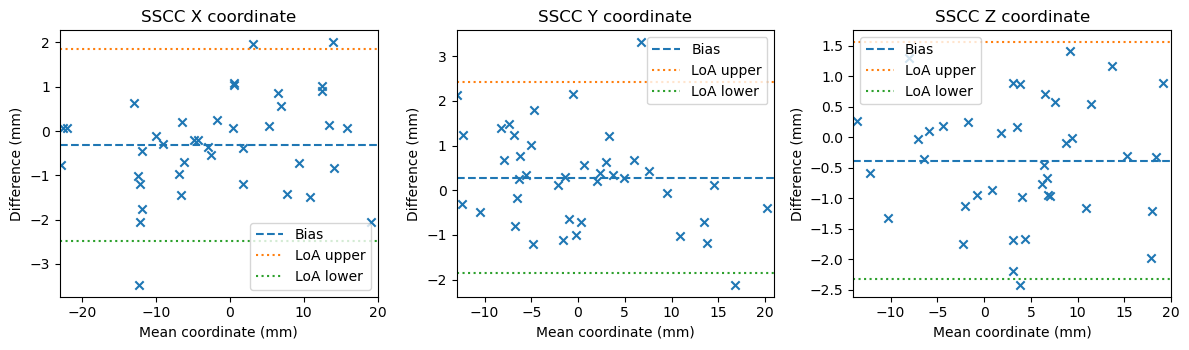

In [2]:
# the stats functions
import numpy as np
import matplotlib.pyplot as plt

def bland_altman_basic(ob1, ob2, ax=None, title="Bland–Altman", xlab="Mean", ylab="Diff"):
    """
    Basic Bland–Altman for 1D paired data.
    Draws bias and limits of agreement (±1.96*SD). Returns (fig, ax).
    """
    ob1 = np.asarray(ob1, float).ravel()
    ob2 = np.asarray(ob2, float).ravel()
    if ob1.size != ob2.size or ob1.size < 3:
        raise ValueError("Need >=3 paired observations with equal length.")

    mean_ob = (ob1 + ob2) / 2.0
    diff_ob = ob1 - ob2
    bias = np.mean(diff_ob)
    sd   = np.std(diff_ob, ddof=1)
    loa_upper = bias + 1.96 * sd
    loa_lower = bias - 1.96 * sd

    created = False
    if ax is None:
        fig, ax = plt.subplots()
        created = True
    else:
        fig = ax.figure

    ax.scatter(mean_ob, diff_ob, marker='x')          # keep default colors
    x_min, x_max = np.floor(mean_ob.min()), np.ceil(mean_ob.max())
    ax.plot([x_min, x_max], [bias, bias], linestyle='--', label="Bias")
    ax.plot([x_min, x_max], [loa_upper, loa_upper], linestyle=':', label="LoA upper")
    ax.plot([x_min, x_max], [loa_lower, loa_lower], linestyle=':', label="LoA lower")
    ax.set_xlim(x_min, x_max)
    y_min = min(diff_ob.min(), loa_lower)
    y_max = max(diff_ob.max(), loa_upper)
    pad = 0.05 * max(1.0, (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend()
    return fig, ax


def bland_altman_3d_per_axis(pts1_mm, pts2_mm, roi_name="ROI"):
    """
    Basic per-axis Bland–Altman for 3D landmarks.
    pts*_mm: arrays of shape (N, 3) in millimetres, matched point-wise.
    Returns (fig, axes).
    """
    pts1_mm = np.asarray(pts1_mm, float)
    pts2_mm = np.asarray(pts2_mm, float)
    if pts1_mm.shape != pts2_mm.shape or pts1_mm.ndim != 2 or pts1_mm.shape[1] != 3:
        raise ValueError("pts1_mm and pts2_mm must be (N, 3) arrays.")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    labels = ["X", "Y", "Z"]

    for i, lab in enumerate(labels):
        bland_altman_basic(
            pts1_mm[:, i],
            pts2_mm[:, i],
            ax=axes[i],
            title=f"{roi_name} {lab} coordinate",
            xlab="Mean coordinate (mm)",
            ylab="Difference (mm)",
        )
    fig.tight_layout()
    return fig, axes

# ---- tiny example ----
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    # fake 3D points (N,3)
    p1 = rng.normal(0, 10, size=(40, 3))
    p2 = p1 + np.array([0.4, -0.2, 0.6]) + rng.normal(0, 1.0, size=(40, 3))
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="SSCC")
    plt.show()


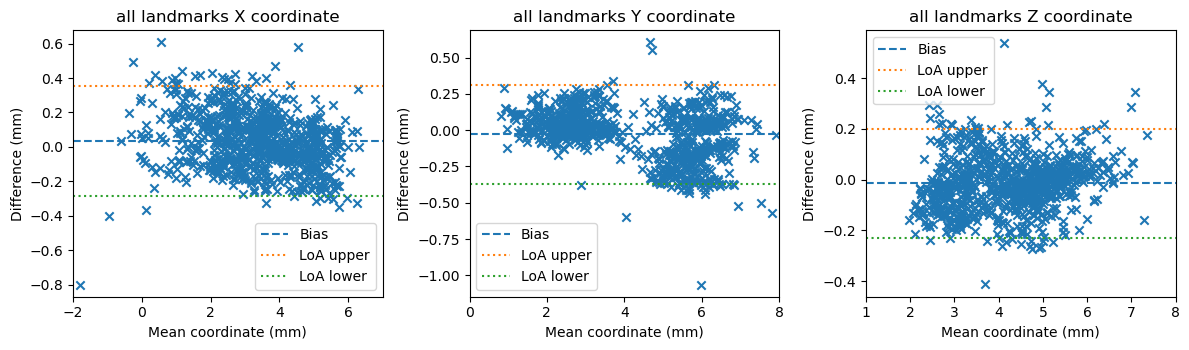

In [3]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = y_test_true.reshape(-1, 3) * 0.15
    p2 = y_test_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="all landmarks")
    plt.show()

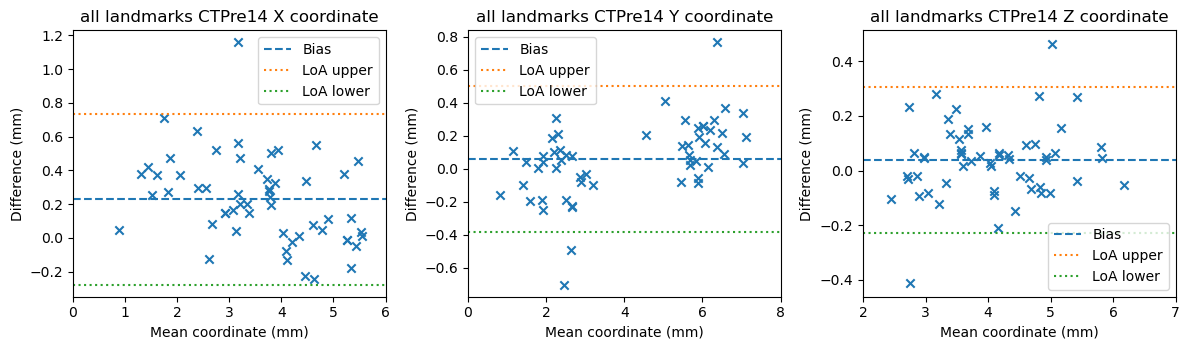

In [4]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = y_CTPre14_true.reshape(-1, 3) * 0.15
    p2 = y_CTPre14_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="all landmarks CTPre14")
    plt.show()

### Confidence intervals

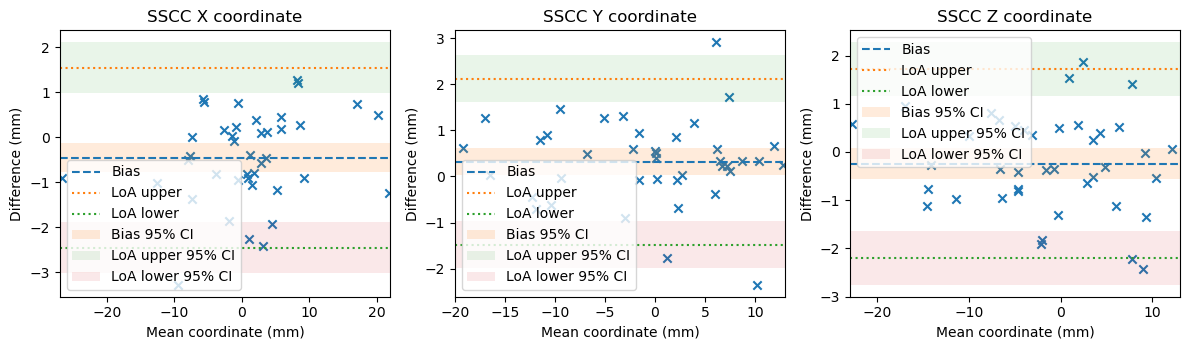

In [5]:
# the stats function
import numpy as np
import matplotlib.pyplot as plt

def _tcrit(df: int, alpha: float = 0.05) -> float:
    """Two-sided t critical value; falls back to ~1.96 if SciPy not installed."""
    try:
        from scipy.stats import t
        return float(t.ppf(1 - alpha/2, df))
    except Exception:
        return 1.96  # Normal approx

def bland_altman_with_ci(
    ob1,
    ob2,
    ax=None,
    title="Bland–Altman (with 95% CIs)",
    xlabel="Mean of methods",
    ylabel="Difference (ob1 − ob2)",
    loa_z: float = 1.96,         # 95% LoA
    alpha: float = 0.05,         # 95% CI bands
):
    """
    Basic Bland–Altman plot with shaded 95% CIs for bias and LoA.

    Parameters
    ----------
    ob1, ob2 : array-like (1D, same length)
        Paired measurements from two methods.
    ax : matplotlib Axes, optional
    loa_z : float
        Z multiplier for LoA (1.96 → ~95%).
    alpha : float
        CI level for shaded bands (0.05 → 95% CI).

    Returns
    -------
    fig, ax, stats : (Figure, Axes, dict)
        stats contains bias, sd, loa_lower/upper and CI bounds.
    """
    x = np.asarray(ob1, float).ravel()
    y = np.asarray(ob2, float).ravel()
    if x.size != y.size or x.size < 3:
        raise ValueError("Need ≥3 paired observations of equal length.")
    n = x.size
    df = n - 1

    mean_ob = (x + y) / 2.0
    diff_ob = x - y

    bias = float(np.mean(diff_ob))
    sd   = float(np.std(diff_ob, ddof=1))
    loa_lower = bias - loa_z * sd
    loa_upper = bias + loa_z * sd

    # CIs (Bland & Altman 1999)
    tcrit = _tcrit(df, alpha=alpha)
    se_bias = sd / np.sqrt(n)
    se_loa = sd * np.sqrt(1.0/n + (loa_z**2) / (2*(n-1)))

    bias_ci = (bias - tcrit*se_bias, bias + tcrit*se_bias)
    loa_lower_ci = (loa_lower - tcrit*se_loa, loa_lower + tcrit*se_loa)
    loa_upper_ci = (loa_upper - tcrit*se_loa, loa_upper + tcrit*se_loa)

    created = False
    if ax is None:
        fig, ax = plt.subplots()
        created = True
    else:
        fig = ax.figure

    # Scatter
    ax.scatter(mean_ob, diff_ob, marker="x")  # (no explicit colors)

    # Horizontal lines
    x_min, x_max = np.floor(mean_ob.min()), np.ceil(mean_ob.max())
    xx = np.array([x_min, x_max], float)
    ax.plot(xx, [bias, bias], linestyle="--", label="Bias")
    ax.plot(xx, [loa_upper, loa_upper], linestyle=":", label="LoA upper")
    ax.plot(xx, [loa_lower, loa_lower], linestyle=":", label="LoA lower")

    # Shaded CI bands
    ax.fill_between(xx, bias_ci[0], bias_ci[1], alpha=0.15, label="Bias 95% CI")
    ax.fill_between(xx, loa_upper_ci[0], loa_upper_ci[1], alpha=0.10, label="LoA upper 95% CI")
    ax.fill_between(xx, loa_lower_ci[0], loa_lower_ci[1], alpha=0.10, label="LoA lower 95% CI")

    # Axes, labels
    y_min = min(diff_ob.min(), loa_lower_ci[0])
    y_max = max(diff_ob.max(), loa_upper_ci[1])
    pad = 0.05 * max(1.0, (y_max - y_min))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

    stats = dict(
        n=n, bias=bias, sd=sd,
        loa_lower=loa_lower, loa_upper=loa_upper,
        bias_ci=bias_ci, loa_lower_ci=loa_lower_ci, loa_upper_ci=loa_upper_ci,
    )
    return fig, ax, stats


# ---------- Optional: per-axis 3D helper (simple) ----------

def bland_altman_3d_per_axis_with_ci(pts1_mm, pts2_mm, roi_name="ROI"):
    """
    Per-axis BA with 95% CI bands for 3D landmarks.
    pts*_mm: arrays (N, 3) in millimetres.
    """
    pts1_mm = np.asarray(pts1_mm, float)
    pts2_mm = np.asarray(pts2_mm, float)
    if pts1_mm.shape != pts2_mm.shape or pts1_mm.ndim != 2 or pts1_mm.shape[1] != 3:
        raise ValueError("pts1_mm and pts2_mm must be (N, 3) arrays.")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    for i, lab in enumerate(["X", "Y", "Z"]):
        bland_altman_with_ci(
            pts1_mm[:, i],
            pts2_mm[:, i],
            ax=axes[i],
            title=f"{roi_name} {lab} coordinate",
            xlabel="Mean coordinate (mm)",
            ylabel="Difference (mm)"
        )
    fig.tight_layout()
    return fig, axes


# ---- tiny demo ----
if __name__ == "__main__":
    rng = np.random.default_rng(1)
    p1 = rng.normal(0, 10, size=(40, 3))
    p2 = p1 + np.array([0.4, -0.2, 0.6]) + rng.normal(0, 1.0, size=(40, 3))
    fig, axes = bland_altman_3d_per_axis_with_ci(p1, p2, roi_name="SSCC")
    plt.show()


### hypothesis testing

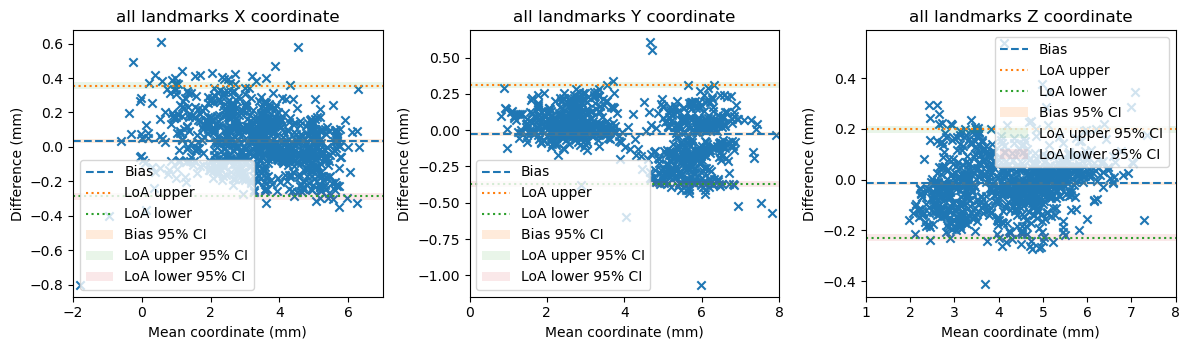

In [6]:
if __name__ == "__main__":
    p1 = y_test_true.reshape(-1, 3) * 0.15
    p2 = y_test_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis_with_ci(p1, p2, roi_name="all landmarks")
    plt.show()

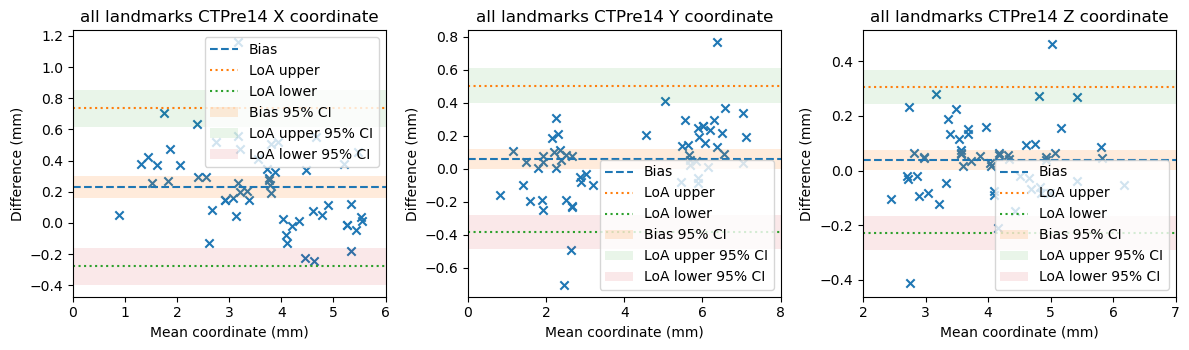

In [7]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = y_CTPre14_true.reshape(-1, 3) * 0.15
    p2 = y_CTPre14_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis_with_ci(p1, p2, roi_name="all landmarks CTPre14")
    plt.show()  

## hypothesis validation

In [9]:
print(y_CTPre14_pred[:5]*0.15)

[[[4.3098845 1.4591062 5.036198 ]
  [2.677915  5.4131327 3.8895118]]

 [[3.7224045 2.5923567 4.3083587]
  [1.6799202 6.382969  3.081382 ]]

 [[4.574238  2.9002624 4.0218086]
  [3.2477295 7.0153537 2.9414542]]

 [[5.539054  1.0909562 4.135729 ]
  [3.545081  4.838716  2.7302794]]

 [[2.8538916 2.289327  4.902001 ]
  [1.1231321 6.321463  4.6764555]]]
